187.0


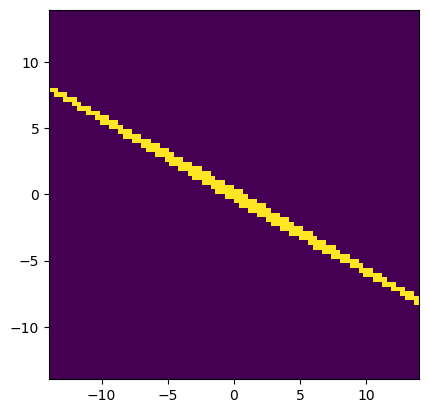

In [37]:
import numpy as np
from fit_gaussian import (
    fit_gaussian_2d_smooth_heaviside,
    popt_get_mu_cov,
    fit_and_plot_smooth_heaviside,
)
import matplotlib.pyplot as plt

L = 16e-3
d = 1.4e-3
L1 = 0.2
L2 = 0.2 * 2.35
RANGE = 800 * (np.pi / 180)
D = 80
tList1 = np.linspace(-RANGE, RANGE, D)
tList2 = np.linspace(-RANGE, RANGE, D)
X, Y = np.meshgrid(tList1, tList2)


def theta(x, x0, w):
    # -w/2 < x < w/2, 0 otherwise
    return np.where(np.abs(x - x0) < w / 2, 1, 0)


def f(x, t):
    x1 = x + (L / 2) * np.tan(t)
    x2 = x - (L / 2) * np.tan(t)
    return theta(np.sqrt(x1**2 + x2**2), 0, d)
    # return theta(x1, 0, d)


def g(x, y, tx, ty):
    x1 = x + (L / 2) * np.tan(tx)
    x2 = x - (L / 2) * np.tan(tx)
    y1 = y + (L / 2) * np.tan(ty)
    y2 = y - (L / 2) * np.tan(ty)
    return theta(np.sqrt(x1**2 + y1**2), 0, d) * theta(np.sqrt(x2**2 + y2**2), 0, d)


def t_mirror(t):
    return 8e-3 * (t / (2 * np.pi))


def calc_data(crosstalk_matrix, zero, scan_type="xxdot"):
    Z = np.zeros((D, D))

    for i in range(D):
        for j in range(D):
            tknob1 = X[i, j]
            tknob2 = Y[i, j]
            if scan_type == "xxdot":
                tx1 = t_mirror(tknob1 + zero[0])
                tx2 = t_mirror(tknob2 + zero[2])
                tx_vec = np.array([tx1, tx2])
                cm = crosstalk_matrix(tknob1, tknob2)
                ty_vec = np.dot(cm, tx_vec)
                ty1 = t_mirror(zero[1]) + ty_vec[0]
                ty2 = t_mirror(zero[3]) + ty_vec[1]
            elif scan_type == "yydot":
                ty1 = t_mirror(tknob1 + zero[1])
                ty2 = t_mirror(tknob2 + zero[3])
                ty_vec = np.array([ty1, ty2])
                cm = crosstalk_matrix(tknob1, tknob2)
                # tx_vec = np.dot(np.linalg.inv(cm), ty_vec)
                tx_vec = np.dot(cm, ty_vec)
                tx1 = t_mirror(zero[0]) + tx_vec[0]
                tx2 = t_mirror(zero[2]) + tx_vec[1]
            #
            tx = tx1 + tx2
            ty = ty1 + ty2
            x = -L1 * np.tan(tx1 * 2) + L2 * np.tan(tx * 2)
            y = -L1 * np.tan(ty1 * 2) + L2 * np.tan(ty * 2)
            transmission = g(x, y, tx, ty)
            Z[i, j] = transmission
    return Z


crosstalk_matrix_none = lambda tknob1, tknob2: np.array([[0, 0], [0, 0]])
crosstalk_matrix = lambda tknob1, tknob2: np.array([[0.1,0], [0, 0.3]])
crosstalk_matrix_rot = lambda tknob1, tknob2: np.array(
    [[0.1+tknob1 / 6,0], [0, 0.3 + tknob1 / 10]]
)


def iterate_zero(N,zero):
    zeroList = []
    zeroList.append(zero.copy())
    muList = []

    for i in range(N):
        for scan_type in ["xxdot","yydot"]:
            Z = calc_data(crosstalk_matrix=crosstalk_matrix, zero=zero, scan_type=scan_type)
            print(np.sum(Z))
            # popt = fit_and_plot_smooth_heaviside(X, Y, Z)
            popt = fit_gaussian_2d_smooth_heaviside(X, Y, Z)
            print(popt)
            mu, cov = popt_get_mu_cov(popt)
            print(mu)
            muList.append(mu)
            #
            if scan_type == "xxdot":
                zero[0]+=mu[0]
                zero[2]+=mu[1]
            else:
                zero[1]+=mu[0]
                zero[3]+=mu[1]
        zeroList.append(zero.copy())
    return zeroList,muList

# muList = []
# LList = []
# for i in range(-2,3):
#     L=i*0.5
#     LList.append(L)
#     zero=np.array([0, L, 0, L*(-0.67)],dtype=float)
#     Z = calc_data(crosstalk_matrix=crosstalk_matrix_none, zero=zero, scan_type="xxdot")
#     print(np.sum(Z))
#     popt = fit_and_plot_smooth_heaviside(X, Y, Z)
#     # print(popt)
#     mu, cov = popt_get_mu_cov(popt)
#     print(mu)
#     muList.append(mu)
L=-0.1
zero=np.array([+(1/0.2)*L, 0, -(1/0.3)*L, L],dtype=float)
Z = calc_data(crosstalk_matrix=crosstalk_matrix_none, zero=zero, scan_type="xxdot")
print(np.sum(Z))
# popt = fit_and_plot_smooth_heaviside(X, Y, Z)
plt.imshow(Z, extent=(-RANGE, RANGE, -RANGE, RANGE), origin="lower")
# print(popt)
# mu, cov = popt_get_mu_cov(popt)
# print(mu)


267.0


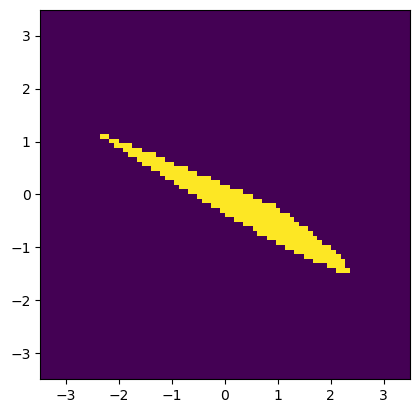

In [34]:
L=-0.5
zero=np.array([+(1/0.2)*L, 0, -(1/0.3)*L, L],dtype=float)
Z = calc_data(crosstalk_matrix=crosstalk_matrix, zero=zero, scan_type="xxdot")
print(np.sum(Z))
# popt = fit_and_plot_smooth_heaviside(X, Y, Z)
plt.imshow(Z, extent=(-RANGE, RANGE, -RANGE, RANGE), origin="lower")

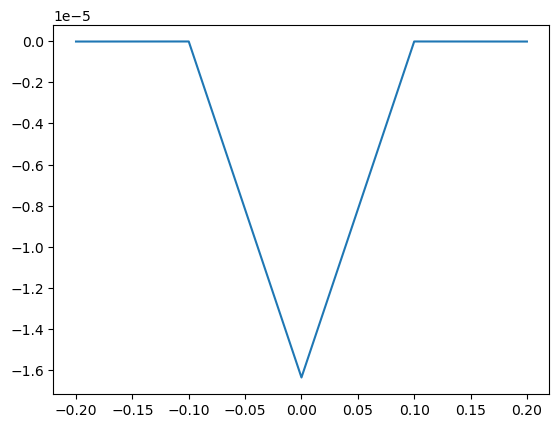

In [27]:
plt.plot(LList,xList)

In [25]:
import string

ab = string.ascii_uppercase
for i in range(len(zeroList)):
    if (i%2==1):
        print("mu xxdot = ",muList[(i-1)])
        print("mu yydot = ",muList[i])
    print(ab[i], zeroList[i])


A [0. 0. 2. 0.]
mu xxdot =  [ 1.53182535 -2.90810454]
mu yydot =  [ 1.50208537 -0.88405263]
B [ 1.53182535  1.50208537 -0.90810454 -0.88405263]
C [-1.53182535 -1.50208537  4.90810454  0.88405263]
mu xxdot =  [ 1.82166659 -5.10192002]
mu yydot =  [ 2.24898203 -1.36253708]
D [ 0.28984124  0.74689666 -0.19381548 -0.47848445]
E [-3.35349194 -3.75106741 10.01002457  2.2465897 ]


In [11]:
Z = calc_data(crosstalk_matrix=crosstalk_matrix_rot, zero=zero, scan_type="xxdot")

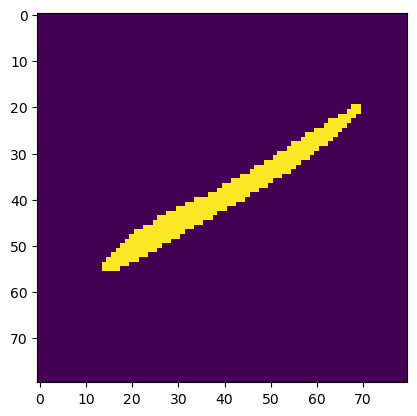

In [12]:
plt.imshow(Z)